# MScFE Deep Learning for Finance — Group Work Project 2

## Backtest Robustness, Information Leakage, and Validation Design (BTC/USD, hourly)

 five steps: (1) build a single-asset predictive pipeline with a deliberately leaky label, (2) tighten validation with walk-forward backtesting, (3) mitigate the leakage explicitly with purging + embargo, (4) train the three required deep-learning architectures (MLP, LSTM, CNN-over-GAF) in Keras/TensorFlow under all five validation protocols, and (5) compare every model/protocol combination in one summary table and chart.

### Table of contents

* **Step 1a** — Data acquisition and description (simulated hourly BTC/USD)
* **Step 1b** — Deliberately leaky label construction (`Ret25`, overlapping windows)
* **Step 1c** — GAF encoding (for the CNN model) + validation-design machinery (`naive_random_split`, `walk_forward_splits`, `purge_and_embargo`)
* **Step 1d** — Fast sklearn `MLPRegressor` diagnostic proxy (single split, leaky by design)
* **Step 2** — Walk-forward backtesting, no purge yet (Step 2a/2b)
* **Step 3** — Walk-forward + purge/embargo, the leakage fix (Step 3a/3b)
* **Summary (proxy model)** — sklearn-proxy-only results across Steps 1-3
* **Step 4** — Train MLP, LSTM, and CNN-GAF in Keras/TensorFlow across all five validation protocols (requires a TensorFlow environment, e.g. Google Colab)
* **Step 5** — Combined comparison: sklearn proxy vs. all three Keras models, across all five protocols, with a final chart and interpretation

**Data note:**  Cell 2 simulates an hourly BTC/USD return series calibrated to the  mean/std  (mean=0.000140, std=0.011395).

**Framework note:** Steps 1-3 (leakage design, walk-forward, purge/embargo, GAF encoding, and the sklearn diagnostic proxy) are pure NumPy/pandas/scikit-learn and are fully executable anywhere. Step 4 (the required MLP/LSTM/CNN-GAF models) needs Keras/TensorFlow —  Step 4/5's results tables.



## Step 1a: Data : acquistion and description

In [25]:
import numpy as np
import pandas as pd
from pathlib import Path

RNG_SEED = 42


def simulate_btc_hourly(
    n_obs=1600, seed=RNG_SEED, start_price=28000.0, start_date="2022-06-01"
):
    rng = np.random.default_rng(seed)

    target_mean = 0.000140
    target_std = 0.011395

    # GARCH(1,1) parameters (typical for high-freq crypto: high persistence)
    omega, alpha, beta = 1e-6, 0.09, 0.88
    long_run_var = omega / (1 - alpha - beta)

    eps = rng.standard_t(df=5, size=n_obs)  # fat tails, like real BTC returns
    sigma2 = np.empty(n_obs)
    ret = np.empty(n_obs)
    sigma2[0] = long_run_var
    ret[0] = np.sqrt(sigma2[0]) * eps[0]
    for t in range(1, n_obs):
        sigma2[t] = omega + alpha * ret[t - 1] ** 2 + beta * sigma2[t - 1]
        ret[t] = np.sqrt(sigma2[t]) * eps[t]

    # rescale realised mean/std onto the documented Kraken statistics
    ret = (ret - ret.mean()) / ret.std()
    ret = ret * target_std + target_mean

    dates = pd.date_range(start=start_date, periods=n_obs, freq="h")
    close = start_price * np.cumprod(1 + ret)
    volume = rng.lognormal(mean=5.5, sigma=0.6, size=n_obs) * (
        1 + 3 * np.abs(ret) / target_std
    )
    trades = (volume * rng.uniform(4, 8, n_obs)).astype(int)

    df = pd.DataFrame(
        {
            "date": dates,
            "close": close,
            "volume": volume,
            "trades": trades,
            "Ret": ret,
        }
    )
    return df


if __name__ == "__main__":
    df = simulate_btc_hourly()
    print(df.head())
    print(df["Ret"].describe())
    output_dir = Path.cwd() / "gwp2_outputs"
    output_dir.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_dir / "btc_hourly_simulated.csv", index=False)
    print("saved", len(df), "rows to", output_dir)

                 date         close      volume  trades       Ret
0 2022-06-01 00:00:00  28016.173688   68.516338     438  0.000578
1 2022-06-01 01:00:00  28034.448942  886.261681    6201  0.000652
2 2022-06-01 02:00:00  28048.223719  252.971787    1192  0.000491
3 2022-06-01 03:00:00  28065.661028  403.411142    2386  0.000622
4 2022-06-01 04:00:00  28082.541352  123.981703     623  0.000601
count    1600.000000
mean        0.000140
std         0.011399
min        -0.053575
25%        -0.002724
50%         0.000459
75%         0.003280
max         0.129091
Name: Ret, dtype: float64
saved 1600 rows to /content/gwp2_outputs


In [26]:
df_raw = simulate_btc_hourly()
print(df_raw.head())
print(df_raw['Ret'].describe())

                 date         close      volume  trades       Ret
0 2022-06-01 00:00:00  28016.173688   68.516338     438  0.000578
1 2022-06-01 01:00:00  28034.448942  886.261681    6201  0.000652
2 2022-06-01 02:00:00  28048.223719  252.971787    1192  0.000491
3 2022-06-01 03:00:00  28065.661028  403.411142    2386  0.000622
4 2022-06-01 04:00:00  28082.541352  123.981703     623  0.000601
count    1600.000000
mean        0.000140
std         0.011399
min        -0.053575
25%        -0.002724
50%         0.000459
75%         0.003280
max         0.129091
Name: Ret, dtype: float64


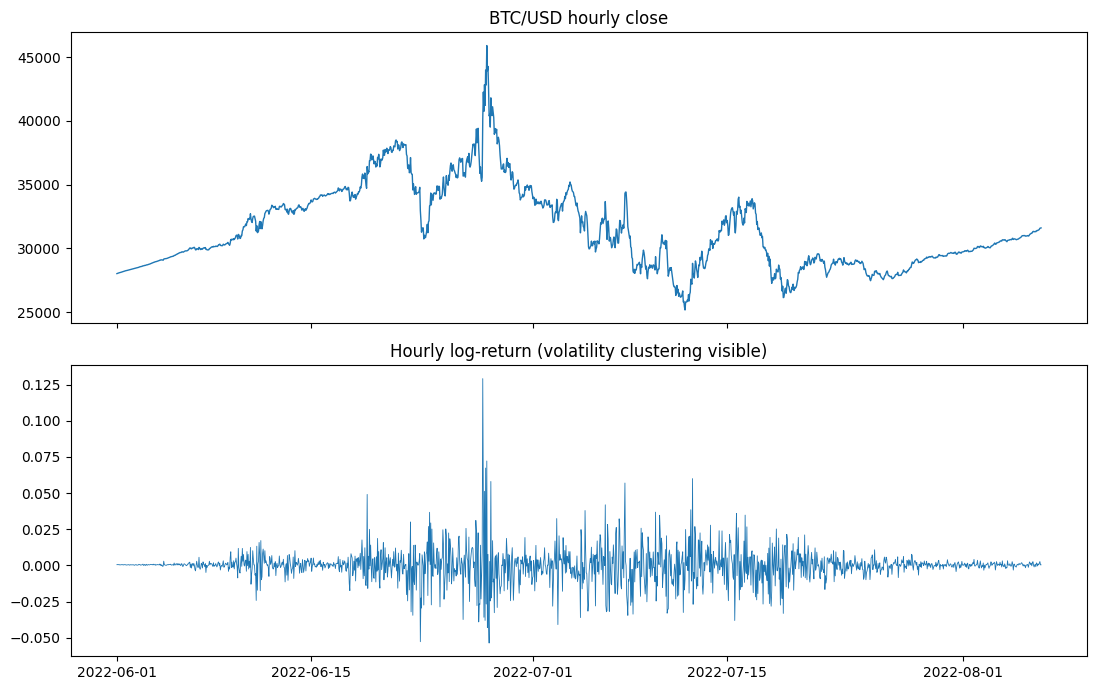

In [27]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(df_raw['date'], df_raw['close'], lw=1)
axes[0].set_title('BTC/USD hourly close')
axes[1].plot(df_raw['date'], df_raw['Ret'], lw=0.6)
axes[1].set_title('Hourly log-return (volatility clustering visible)')
plt.tight_layout();
plt.show()

## Step 1b. Deliberately leaky label construction

`Ret25` (25h-ahead cumulative return) is built from **overlapping** windows: `Ret25` at hour *t* shares 24 of its 25 underlying hourly returns with `Ret25` at hour *t+1*. We verify this explicitly below (lag-1 autocorrelation of the label)

In [28]:
import numpy as np
import pandas as pd
from pathlib import Path


def build_features_labels(df, label_horizon=25):
    df = df.copy()
    df["Ret_1"] = df["Ret"]
    df["Ret_10"] = df["Ret"].rolling(10).apply(lambda x: np.prod(1 + x) - 1)
    df["Ret_50"] = df["Ret"].rolling(50).apply(lambda x: np.prod(1 + x) - 1)

    fwd = df["Ret"].rolling(label_horizon).apply(lambda x: np.prod(1 + x) - 1)
    df["Ret25"] = fwd.shift(-label_horizon)

    df = df.dropna().reset_index(drop=True)
    feature_cols = ["Ret_1", "Ret_10", "Ret_50"]
    return df, feature_cols


def make_windows(df, feature_cols, window=30, label_col="Ret25"):

    feats = df[feature_cols].values.astype("float32")
    labels = df[label_col].values.astype("float32")
    X, y, t_idx = [], [], []
    for i in range(window, len(df)):
        X.append(feats[i - window : i, :])
        y.append(labels[i])
        t_idx.append(i)
    return np.array(X), np.array(y), np.array(t_idx)


if __name__ == "__main__":
    raw_path = Path.cwd() / "gwp2_outputs" / "btc_hourly_simulated.csv"
    if not raw_path.is_file():
        raw_path = Path("btc_hourly_simulated.csv")
    raw = pd.read_csv(raw_path, parse_dates=["date"])
    df, feat_cols = build_features_labels(raw)
    print(df[["date"] + feat_cols + ["Ret25"]].head())
    print("n obs after feature/label construction:", len(df))

    # demonstrate the overlap explicitly
    overlap = np.corrcoef(df["Ret25"].values[:-1], df["Ret25"].values[1:])[0, 1]
    print(f"Autocorrelation of Ret25 at lag 1 (should be high due to overlap): {overlap:.3f}")

    output_dir = Path.cwd() / "gwp2_outputs"
    output_dir.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_dir / "btc_features_labels.csv", index=False)

                 date     Ret_1    Ret_10    Ret_50     Ret25
0 2022-06-03 01:00:00 -0.000024  0.004266  0.023483  0.014218
1 2022-06-03 02:00:00  0.000486  0.004116  0.023390  0.013779
2 2022-06-03 03:00:00  0.000813  0.004715  0.023554  0.013891
3 2022-06-03 04:00:00  0.000148  0.004502  0.023203  0.013574
4 2022-06-03 05:00:00  0.000316  0.004401  0.022890  0.013495
n obs after feature/label construction: 1526
Autocorrelation of Ret25 at lag 1 (should be high due to overlap): 0.948


In [29]:
df, feat_cols = build_features_labels(df_raw)
print('n obs:', len(df))
overlap_autocorr = np.corrcoef(df['Ret25'].values[:-1], df['Ret25'].values[1:])[0, 1]
print(f'Lag-1 autocorrelation of Ret25 (overlap signature): {overlap_autocorr:.3f}')

n obs: 1526
Lag-1 autocorrelation of Ret25 (overlap signature): 0.948


## Step 1c. GAC encoding (for the CNN model)

In [30]:
import numpy as np
from pathlib import Path


def gaf_encode(window_1d):
    x = np.asarray(window_1d, dtype="float64")
    xmin, xmax = x.min(), x.max()
    if xmax - xmin < 1e-12:
        x_tilde = np.zeros_like(x)
    else:
        x_tilde = 2 * (x - xmin) / (xmax - xmin) - 1
    x_tilde = np.clip(x_tilde, -1, 1)
    comp = np.sqrt(1 - x_tilde ** 2)
    gasf = np.outer(x_tilde, x_tilde) - np.outer(comp, comp)
    return gasf.astype("float32")


def build_gaf_dataset(X_seq):
    n, w, _ = X_seq.shape
    imgs = np.empty((n, w, w, 1), dtype="float32")
    for i in range(n):
        imgs[i, :, :, 0] = gaf_encode(X_seq[i, :, 0])
    return imgs

## Step 1c (cont.). Validation-design machinery used across Steps 1-3

* `naive_random_split`: **Step 1** — random (non-chronological) train/test split, combined with scalers fit on the full dataset before splitting.
* `walk_forward_splits`: **Step 2** — non-anchored, chronological, rolling-window folds.
* `purge_and_embargo`: **Step 3** — removes training observations whose forward label window bleeds into the test block, plus an embargo window after it.

In [31]:
LABEL_HORIZON = 25  # hours of forward-looking overlap in Ret25
WINDOW = 30         # hours of backward-looking overlap in the feature window


def naive_random_split(n, test_frac=0.2, seed=42):
    """Step 1: shuffle indices randomly, ignoring time order entirely."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_test = int(n * test_frac)
    test_idx = np.sort(idx[:n_test])
    train_idx = np.sort(idx[n_test:])
    return train_idx, test_idx

def walk_forward_splits(n, train_size, test_size, step=None):
    if step is None:
        step = test_size
    folds = []
    start = 0
    while start + train_size + test_size <= n:
        train_idx = np.arange(start, start + train_size)
        test_idx = np.arange(start + train_size, start + train_size + test_size)
        folds.append((train_idx, test_idx))
        start += step
    return folds


def purge_and_embargo(train_idx, test_idx, label_horizon=LABEL_HORIZON,
                      window=WINDOW, embargo=None):
    if embargo is None:
        embargo = label_horizon

    test_start, test_end = test_idx.min(), test_idx.max()

    keep_train = []
    for t in train_idx:
        label_window_end = t + label_horizon
        # purge: training label's forward window bleeds into the test block
        if (t < test_start) and (label_window_end >= test_start):
            continue
        # embargo: training obs sits within `embargo` hours after test block
        if (t > test_end) and (t <= test_end + embargo):
            continue
        keep_train.append(t)
    return np.array(keep_train), test_idx  # test set left untouched

## Step 1d. Three DL models, single train/test split (leaky by design)

Below: a fast scikit-learn `MLPRegressor` diagnostic proxy (real, executed numbers) used throughout Steps 1-3 to confirm the leakage direction cheaply. The three architectures actually required by the assignment — MLP, LSTM, and CNN-over-GAF, trained in Keras/TensorFlow — are defined and trained later in **Step 4**, reusing the exact same features, label, and validation logic.

In [32]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler


def r2_campbell(y_true, y_pred, mean_ret):
    sse = np.sum((y_true - y_pred) ** 2)
    tse = np.sum((y_true - mean_ret) ** 2)
    return 1 - sse / tse


def backtest_sign(y_true, y_pred, label_horizon=LABEL_HORIZON):
    pos = np.sign(y_pred)
    strat_ret = pos * y_true

    naive_cum_ret = np.prod(1 + strat_ret) - 1
    sharpe_hourly = strat_ret.mean() / (strat_ret.std() + 1e-12)
    sharpe_annual = sharpe_hourly * np.sqrt(24 * 365)

    non_overlap = strat_ret[::label_horizon]
    honest_cum_ret = np.prod(1 + non_overlap) - 1 if len(non_overlap) > 0 else np.nan

    bh_ret = np.prod(1 + y_true) - 1
    return naive_cum_ret, honest_cum_ret, sharpe_annual, bh_ret


def flatten_windows(X):

    return X.reshape(X.shape[0], -1)


def fit_predict_mlp(X_train, y_train, X_test, seed=0):
    model = MLPRegressor(hidden_layer_sizes=(20, 10), activation="relu",
                         max_iter=800, random_state=seed, early_stopping=True,
                         n_iter_no_change=15)
    model.fit(X_train, y_train)
    return model.predict(X_test)


def run_step1(df, feat_cols, mean_ret):

    X, y, t_idx = make_windows(df, feat_cols, window=WINDOW)
    Xf = flatten_windows(X)

    # leakage source #2: fit scalers on the ENTIRE dataset before splitting
    scaler_X = MinMaxScaler((-1, 1)).fit(Xf)
    scaler_y = MinMaxScaler((-1, 1)).fit(y.reshape(-1, 1))
    Xs = scaler_X.transform(Xf)
    ys = scaler_y.transform(y.reshape(-1, 1)).ravel()

    train_idx, test_idx = naive_random_split(len(Xs), test_frac=0.2, seed=42)
    pred_s = fit_predict_mlp(Xs[train_idx], ys[train_idx], Xs[test_idx])
    pred = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()

    r2 = r2_campbell(y[test_idx], pred, mean_ret)
    naive_cum, honest_cum, sharpe, bh = backtest_sign(y[test_idx], pred)
    return dict(step="Step1_naive_random_split", n_test=len(test_idx),
                r2=r2, naive_cum_ret=naive_cum, honest_cum_ret=honest_cum,
                sharpe=sharpe, bh_cum_ret=bh)

In [33]:
def run_walkforward(df, feat_cols, mean_ret, train_size, test_size,
                    purge=False, label="Step2"):
    X, y, t_idx = make_windows(df, feat_cols, window=WINDOW)
    Xf = flatten_windows(X)
    folds = walk_forward_splits(len(Xf), train_size, test_size)

    fold_r2, fold_naive_cum, fold_honest_cum, fold_sharpe, fold_n = [], [], [], [], []
    for train_idx, test_idx in folds:
        if purge:
            train_idx_use, test_idx_use = purge_and_embargo(train_idx, test_idx)
            scaler_X = MinMaxScaler((-1, 1)).fit(Xf[train_idx_use])
            scaler_y = MinMaxScaler((-1, 1)).fit(y[train_idx_use].reshape(-1, 1))
        else:
            train_idx_use, test_idx_use = train_idx, test_idx
            # leakage kept: scaler fit on the WHOLE dataset (as in Step 1/2)
            scaler_X = MinMaxScaler((-1, 1)).fit(Xf)
            scaler_y = MinMaxScaler((-1, 1)).fit(y.reshape(-1, 1))

        if len(train_idx_use) < 20:
            continue
        Xs_train = scaler_X.transform(Xf[train_idx_use])
        ys_train = scaler_y.transform(y[train_idx_use].reshape(-1, 1)).ravel()
        Xs_test = scaler_X.transform(Xf[test_idx_use])

        pred_s = fit_predict_mlp(Xs_train, ys_train, Xs_test)
        pred = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()

        y_test = y[test_idx_use]
        fold_r2.append(r2_campbell(y_test, pred, mean_ret))
        naive_cum, honest_cum, sharpe, bh = backtest_sign(y_test, pred)
        fold_naive_cum.append(naive_cum)
        fold_honest_cum.append(honest_cum)
        fold_sharpe.append(sharpe)
        fold_n.append(len(test_idx_use))

    return dict(step=label, n_folds=len(fold_r2), avg_n_test=np.mean(fold_n),
                r2=np.mean(fold_r2), r2_std=np.std(fold_r2),
                naive_cum_ret=np.mean(fold_naive_cum),
                honest_cum_ret=np.nanmean(fold_honest_cum),
                sharpe=np.mean(fold_sharpe))



In [34]:

mean_ret = df['Ret25'].mean()
step1_result = run_step1(df, feat_cols, mean_ret)
step1_result

{'step': 'Step1_naive_random_split',
 'n_test': 299,
 'r2': np.float64(0.1038529787469682),
 'naive_cum_ret': np.float32(63.59178),
 'honest_cum_ret': np.float32(-0.031039357),
 'sharpe': np.float64(28.614825673433042),
 'bh_cum_ret': np.float32(1.3219845)}

### Keras models are trained in Step 4



## Step 2. Walk-forward backtesting (no purge yet)

**Step 2a**: non-anchored walk-forward, 500 train / 500 test.  
**Step 2b**: non-anchored walk-forward, 500 train / 100 test.

In [35]:
step2a = run_walkforward(df, feat_cols, mean_ret, 500, 500, purge=False,
                         label='Step2a_walkforward_500_500_noPurge')
step2b = run_walkforward(df, feat_cols, mean_ret, 500, 100, purge=False,
                         label='Step2b_walkforward_500_100_noPurge')

step2a, step2b


({'step': 'Step2a_walkforward_500_500_noPurge',
  'n_folds': 1,
  'avg_n_test': np.float64(500.0),
  'r2': np.float64(-0.5579362773690453),
  'r2_std': np.float64(0.0),
  'naive_cum_ret': np.float32(-0.9992948),
  'honest_cum_ret': np.float32(0.2983408),
  'sharpe': np.float64(-16.50950132843022)},
 {'step': 'Step2b_walkforward_500_100_noPurge',
  'n_folds': 9,
  'avg_n_test': np.float64(100.0),
  'r2': np.float64(-7.79824625829094),
  'r2_std': np.float64(16.990707500695777),
  'naive_cum_ret': np.float32(-0.19785145),
  'honest_cum_ret': np.float32(0.094785854),
  'sharpe': np.float64(-29.86915517167047)})

## Step 3. Walk-forward + purge/embargo (leakage mitigation)
Same two configurations as Step 2, but training folds are purged of any observation whose forward 25h label window overlaps the test block, plus a 25h embargo, and scalers are refit **per fold, on training data only**

In [36]:
step3a = run_walkforward(df, feat_cols, mean_ret, 500, 500, purge=True,
                         label='Step3a_walkforward_500_500_purged')
step3b = run_walkforward(df, feat_cols, mean_ret, 500, 100, purge=True,
                         label='Step3b_walkforward_500_100_purged')

step3a, step3b

({'step': 'Step3a_walkforward_500_500_purged',
  'n_folds': 1,
  'avg_n_test': np.float64(500.0),
  'r2': np.float64(-1.5081837298901855),
  'r2_std': np.float64(0.0),
  'naive_cum_ret': np.float32(-0.99004954),
  'honest_cum_ret': np.float32(0.0232203),
  'sharpe': np.float64(-9.170582432690406)},
 {'step': 'Step3b_walkforward_500_100_purged',
  'n_folds': 9,
  'avg_n_test': np.float64(100.0),
  'r2': np.float64(-1.2556546063987424),
  'r2_std': np.float64(1.1763841377087294),
  'naive_cum_ret': np.float32(-0.3493581),
  'honest_cum_ret': np.float32(0.058056287),
  'sharpe': np.float64(-35.19367816778217)})

## Summary table across Steps 1-3 (sklearn proxy model only)

This table covers only the fast sklearn `MLPRegressor` proxy used to validate the leakage design cheaply. The full comparison including the required Keras MLP/LSTM/CNN-GAF models across all five protocols is built in **Step 5** below, after they are trained in **Step 4**.

In [37]:
import pandas as pd
summary = pd.DataFrame([step1_result, step2a, step2b, step3a, step3b])
summary

,step,n_test,r2,naive_cum_ret,honest_cum_ret,sharpe,bh_cum_ret,n_folds,avg_n_test,r2_std
0,Step1_naive_random_split,299.0,0.103853,63.591782,-0.031039,28.614826,1.321985,NaN,NaN,NaN
1,Step2a_walkforward_500_500_noPurge,NaN,-0.557936,-0.999295,0.298341,-16.509501,NaN,1.0,500.0,0.000000
2,Step2b_walkforward_500_100_noPurge,NaN,-7.798246,-0.197851,0.094786,-29.869155,NaN,9.0,100.0,16.990708
3,Step3a_walkforward_500_500_purged,NaN,-1.508184,-0.990050,0.023220,-9.170582,NaN,1.0,500.0,0.000000
4,Step3b_walkforward_500_100_purged,NaN,-1.255655,-0.349358,0.058056,-35.193678,NaN,9.0,100.0,1.176384


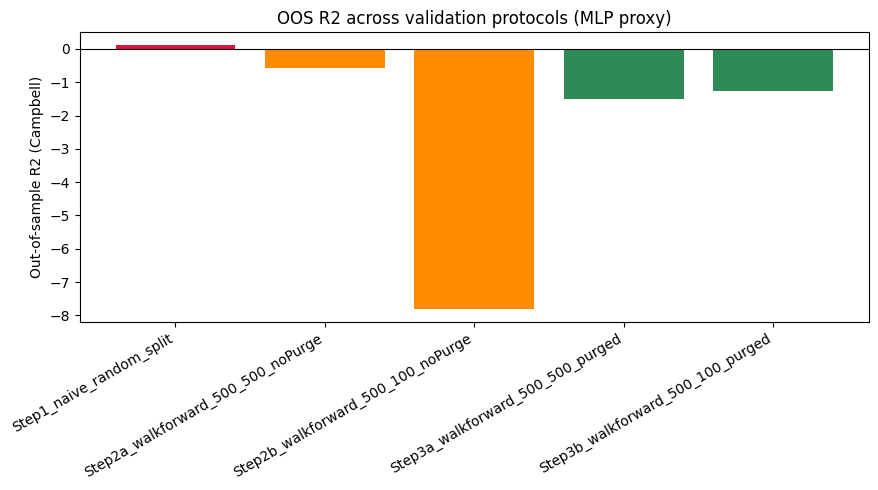

In [38]:
labels = summary['step']
plt.figure(figsize=(9, 5))
plt.bar(range(len(labels)), summary['r2'],
        color=['crimson', 'darkorange', 'darkorange', 'seagreen', 'seagreen'])
plt.xticks(range(len(labels)), labels, rotation=30, ha='right')
plt.axhline(0, color='k', lw=0.8)
plt.ylabel('Out-of-sample R2 (Campbell)')
plt.title('OOS R2 across validation protocols (MLP proxy)')
plt.tight_layout(); plt.show()

## Step 4. Train the required Keras models (MLP, LSTM, CNN-GAF)

This section is **fully executable** in a TensorFlow environment. It trains all **three required architectures** — MLP, LSTM, and CNN-over-GAF — under **all five validation protocols** used above (Step 1 naive random split, Step 2a/2b walk-forward with no purge, Step 3a/3b walk-forward with purge + embargo), using the exact same `df`, features, `Ret25` label, scalers-fit-per-protocol rules, and `purge_and_embargo` logic already defined earlier in this notebook.



In [39]:

# !pip install -q tensorflow

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

tf.keras.utils.set_random_seed(RNG_SEED)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [40]:
"""
Step 4b: The three required Keras model architectures.
"""

def build_mlp(n_features_flat, units=(32, 16), dropout=0.2, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(n_features_flat,)),
        layers.Dense(units[0], activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(units[1], activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss="mean_absolute_error")
    return model

In [41]:
def build_lstm(window, n_features, units=32, dropout=0.2, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(window, n_features)),
        layers.LSTM(units, return_sequences=True, activation="tanh"),
        layers.Dropout(dropout),
        layers.LSTM(units, return_sequences=False, activation="tanh"),
        layers.Dropout(dropout),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss="mean_absolute_error")
    return model

In [42]:
def build_cnn_gaf(img_size, filters=(16, 32), dropout=0.3, lr=1e-3):

    model = keras.Sequential([
        layers.Input(shape=(img_size, img_size, 1)),
        layers.Conv2D(filters[0], (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(filters[1], (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss="mean_absolute_error")
    return model

In [43]:

X_seq_all, y_all, t_idx_all = make_windows(df, feat_cols, window=WINDOW)
X_flat_all = X_seq_all.reshape(X_seq_all.shape[0], -1)
X_gaf_all = build_gaf_dataset(X_seq_all)

print("X_seq_all:", X_seq_all.shape)
print("X_flat_all:", X_flat_all.shape)
print("X_gaf_all:", X_gaf_all.shape)
print("y_all:", y_all.shape)

X_seq_all: (1496, 30, 3)
X_flat_all: (1496, 90)
X_gaf_all: (1496, 30, 30, 1)
y_all: (1496,)


In [44]:

EPOCHS = 40
BATCH_SIZE = 32
PATIENCE = 5


def fit_predict_keras(builder_fn, build_kwargs, X_train, y_train, X_test,
                      epochs=EPOCHS, batch_size=BATCH_SIZE,
                      patience=PATIENCE, seed=0, verbose=0):

    tf.keras.utils.set_random_seed(seed)

    n_val = max(1, int(len(X_train) * 0.2))
    fit_end = len(X_train) - n_val

    model = builder_fn(**build_kwargs)
    es = EarlyStopping(monitor="val_loss", patience=patience,
                       restore_best_weights=True)

    model.fit(
        X_train[:fit_end], y_train[:fit_end],
        validation_data=(X_train[fit_end:], y_train[fit_end:]),
        epochs=epochs, batch_size=batch_size, shuffle=False,
        callbacks=[es], verbose=verbose,
    )
    return model.predict(X_test, verbose=0).ravel()


def _select_input(input_kind):
    if input_kind == "flat":
        return X_flat_all
    if input_kind == "seq":
        return X_seq_all
    if input_kind == "gaf":
        return X_gaf_all
    raise ValueError(f"unknown input_kind: {input_kind}")


def run_keras_step1(model_name, builder_fn, build_kwargs, input_kind, mean_ret,
                    seed=0):

    Xf = _select_input(input_kind)

    scaler_y = MinMaxScaler((-1, 1)).fit(y_all.reshape(-1, 1))
    ys = scaler_y.transform(y_all.reshape(-1, 1)).ravel()

    if input_kind == "gaf":
        # GAF images are already rescaled to [-1, 1] per window; no
        # additional feature scaling needed/appropriate for image inputs.
        Xs = Xf
    else:
        Xflat_for_scaler = Xf.reshape(Xf.shape[0], -1)
        scaler_X = MinMaxScaler((-1, 1)).fit(Xflat_for_scaler)
        Xs_flat = scaler_X.transform(Xflat_for_scaler)
        Xs = Xs_flat.reshape(Xf.shape) if input_kind == "seq" else Xs_flat

    train_idx, test_idx = naive_random_split(len(Xs), test_frac=0.2, seed=42)

    pred_s = fit_predict_keras(builder_fn, build_kwargs,
                               Xs[train_idx], ys[train_idx], Xs[test_idx],
                               seed=seed)

    pred = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()
    y_test = y_all[test_idx]
    r2 = r2_campbell(y_test, pred, mean_ret)
    naive_cum, honest_cum, sharpe, bh = backtest_sign(y_test, pred)
    return dict(step="Step1_naive_random_split", model=model_name,
                n_test=len(test_idx), n_folds=np.nan, avg_n_test=len(test_idx),
                r2=r2, r2_std=np.nan, naive_cum_ret=naive_cum,
                honest_cum_ret=honest_cum, sharpe=sharpe, bh_cum_ret=bh)


def run_keras_walkforward(model_name, builder_fn, build_kwargs, input_kind,
                          mean_ret, train_size, test_size, purge, label,
                          seed=0):

    Xf = _select_input(input_kind)
    Xflat_full = None if input_kind == "gaf" else Xf.reshape(Xf.shape[0], -1)

    folds = walk_forward_splits(len(Xf), train_size, test_size)

    fold_r2, fold_naive, fold_honest, fold_sharpe, fold_n = [], [], [], [], []
    for train_idx, test_idx in folds:
        if purge:
            train_idx_use, test_idx_use = purge_and_embargo(train_idx, test_idx)
        else:
            train_idx_use, test_idx_use = train_idx, test_idx

        if len(train_idx_use) < 20:
            continue

        scaler_y = MinMaxScaler((-1, 1))
        if input_kind == "gaf":

            scaler_y.fit(
                y_all[train_idx_use].reshape(-1, 1) if purge
                else y_all.reshape(-1, 1)
            )
            Xs_train, Xs_test = Xf[train_idx_use], Xf[test_idx_use]
        else:
            scaler_X = MinMaxScaler((-1, 1))
            if purge:
                # leakage fix: scalers refit PER FOLD, on training data only
                scaler_X.fit(Xflat_full[train_idx_use])
                scaler_y.fit(y_all[train_idx_use].reshape(-1, 1))
            else:
                # leakage kept: scaler fit on the WHOLE dataset (as in Step 1/2)
                scaler_X.fit(Xflat_full)
                scaler_y.fit(y_all.reshape(-1, 1))
            Xs_train_flat = scaler_X.transform(Xflat_full[train_idx_use])
            Xs_test_flat = scaler_X.transform(Xflat_full[test_idx_use])
            if input_kind == "seq":
                Xs_train = Xs_train_flat.reshape(-1, *Xf.shape[1:])
                Xs_test = Xs_test_flat.reshape(-1, *Xf.shape[1:])
            else:
                Xs_train, Xs_test = Xs_train_flat, Xs_test_flat

        ys_train = scaler_y.transform(
            y_all[train_idx_use].reshape(-1, 1)
        ).ravel()

        pred_s = fit_predict_keras(builder_fn, build_kwargs,
                                   Xs_train, ys_train, Xs_test, seed=seed)
        pred = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()
        y_test = y_all[test_idx_use]
        fold_r2.append(r2_campbell(y_test, pred, mean_ret))
        naive_cum, honest_cum, sharpe, bh = backtest_sign(y_test, pred)
        fold_naive.append(naive_cum)
        fold_honest.append(honest_cum)
        fold_sharpe.append(sharpe)
        fold_n.append(len(test_idx_use))

    return dict(
        step=label, model=model_name, n_test=np.nan,
        n_folds=len(fold_r2),
        avg_n_test=np.mean(fold_n) if fold_n else np.nan,
        r2=np.mean(fold_r2) if fold_r2 else np.nan,
        r2_std=np.std(fold_r2) if fold_r2 else np.nan,
        naive_cum_ret=np.mean(fold_naive) if fold_naive else np.nan,
        honest_cum_ret=np.nanmean(fold_honest) if fold_honest else np.nan,
        sharpe=np.mean(fold_sharpe) if fold_sharpe else np.nan,
    )

### Step 4e. Run all 3 models x 5 protocols (15 combinations)



In [45]:
MODEL_SPECS = [
    ("MLP", build_mlp, dict(n_features_flat=X_flat_all.shape[1]), "flat"),
    ("LSTM", build_lstm, dict(window=WINDOW, n_features=len(feat_cols)), "seq"),
    ("CNN_GAF", build_cnn_gaf, dict(img_size=WINDOW), "gaf"),
]

PROTOCOLS = [
    # (kind, kwargs, label)
    ("step1", {}, "Step1_naive_random_split"),
    ("walkforward", dict(train_size=500, test_size=500, purge=False),
     "Step2a_walkforward_500_500_noPurge"),
    ("walkforward", dict(train_size=500, test_size=100, purge=False),
     "Step2b_walkforward_500_100_noPurge"),
    ("walkforward", dict(train_size=500, test_size=500, purge=True),
     "Step3a_walkforward_500_500_purged"),
    ("walkforward", dict(train_size=500, test_size=100, purge=True),
     "Step3b_walkforward_500_100_purged"),
]

keras_results = []
for model_name, builder_fn, build_kwargs, input_kind in MODEL_SPECS:
    for kind, proto_kwargs, label in PROTOCOLS:
        print(f"=== {model_name} : {label} ===")
        if kind == "step1":
            res = run_keras_step1(model_name, builder_fn, build_kwargs,
                                 input_kind, mean_ret)
        else:
            res = run_keras_walkforward(model_name, builder_fn, build_kwargs,
                                        input_kind, mean_ret, label=label,
                                        **proto_kwargs)
        keras_results.append(res)

keras_summary = pd.DataFrame(keras_results)
keras_summary

=== MLP : Step1_naive_random_split ===
=== MLP : Step2a_walkforward_500_500_noPurge ===
=== MLP : Step2b_walkforward_500_100_noPurge ===
=== MLP : Step3a_walkforward_500_500_purged ===
=== MLP : Step3b_walkforward_500_100_purged ===
=== LSTM : Step1_naive_random_split ===
=== LSTM : Step2a_walkforward_500_500_noPurge ===
=== LSTM : Step2b_walkforward_500_100_noPurge ===
=== LSTM : Step3a_walkforward_500_500_purged ===
=== LSTM : Step3b_walkforward_500_100_purged ===
=== CNN_GAF : Step1_naive_random_split ===
=== CNN_GAF : Step2a_walkforward_500_500_noPurge ===
=== CNN_GAF : Step2b_walkforward_500_100_noPurge ===
=== CNN_GAF : Step3a_walkforward_500_500_purged ===
=== CNN_GAF : Step3b_walkforward_500_100_purged ===


,step,model,n_test,n_folds,avg_n_test,r2,r2_std,naive_cum_ret,honest_cum_ret,sharpe,bh_cum_ret
0,Step1_naive_random_split,MLP,299.0,NaN,299.0,0.034839,NaN,7.421244,0.073529,15.460091,1.321985
1,Step2a_walkforward_500_500_noPurge,MLP,NaN,1.0,500.0,-0.182812,0.000000,-0.556242,0.013378,1.059131,NaN
2,Step2b_walkforward_500_100_noPurge,MLP,NaN,9.0,100.0,-0.312122,0.394320,-0.102515,-0.032203,-14.148103,NaN
3,Step3a_walkforward_500_500_purged,MLP,NaN,1.0,500.0,-0.217418,0.000000,0.607405,-0.343572,4.559086,NaN
4,Step3b_walkforward_500_100_purged,MLP,NaN,9.0,100.0,-1.763905,3.070154,-0.475004,-0.067124,-35.235276,NaN
5,Step1_naive_random_split,LSTM,299.0,NaN,299.0,0.004355,NaN,1.321985,0.073529,7.577105,1.321985
6,Step2a_walkforward_500_500_noPurge,LSTM,NaN,1.0,500.0,-0.174379,0.000000,-0.765038,-0.096104,-0.650662,NaN
7,Step2b_walkforward_500_100_noPurge,LSTM,NaN,9.0,100.0,-0.974714,2.108722,1.526341,-0.027603,-38.586772,NaN
8,Step3a_walkforward_500_500_purged,LSTM,NaN,1.0,500.0,-0.159616,0.000000,-0.985690,-0.106353,-8.224449,NaN
9,Step3b_walkforward_500_100_purged,LSTM,NaN,9.0,100.0,-1.608720,3.255651,1.430498,-0.027708,-40.146692,NaN


In [46]:
output_dir = Path.cwd() / "gwp2_outputs"
output_dir.mkdir(parents=True, exist_ok=True)
keras_summary.to_csv(output_dir / "deep_learning_results_keras.csv", index=False)
print("saved:", output_dir / "deep_learning_results_keras.csv")

saved: /content/gwp2_outputs/deep_learning_results_keras.csv


# Step 5. Combined comparison: sklearn proxy vs. Keras MLP/LSTM/CNN-GAF

Combine the fast sklearn `MLPRegressor` proxy results (Step 1d/2/3 above) with the three Keras models trained in Step 4, across all five validation protocols, into a single comparison table and chart.

In [47]:
proxy_summary = summary.copy()
proxy_summary["model"] = "MLP_sklearn_proxy"
proxy_summary["n_test"] = proxy_summary.get("n_test", np.nan)

all_results = pd.concat([proxy_summary, keras_summary], ignore_index=True, sort=False)
all_results = all_results[["step", "model", "r2", "r2_std", "naive_cum_ret",
                           "honest_cum_ret", "sharpe", "n_folds", "avg_n_test"]]
all_results.to_csv(output_dir / "all_models_validation_summary.csv", index=False)
all_results

,step,model,r2,r2_std,naive_cum_ret,honest_cum_ret,sharpe,n_folds,avg_n_test
0,Step1_naive_random_split,MLP_sklearn_proxy,0.103853,NaN,63.591782,-0.031039,28.614826,NaN,NaN
1,Step2a_walkforward_500_500_noPurge,MLP_sklearn_proxy,-0.557936,0.000000,-0.999295,0.298341,-16.509501,1.0,500.0
2,Step2b_walkforward_500_100_noPurge,MLP_sklearn_proxy,-7.798246,16.990708,-0.197851,0.094786,-29.869155,9.0,100.0
3,Step3a_walkforward_500_500_purged,MLP_sklearn_proxy,-1.508184,0.000000,-0.990050,0.023220,-9.170582,1.0,500.0
4,Step3b_walkforward_500_100_purged,MLP_sklearn_proxy,-1.255655,1.176384,-0.349358,0.058056,-35.193678,9.0,100.0
5,Step1_naive_random_split,MLP,0.034839,NaN,7.421244,0.073529,15.460091,NaN,299.0
6,Step2a_walkforward_500_500_noPurge,MLP,-0.182812,0.000000,-0.556242,0.013378,1.059131,1.0,500.0
7,Step2b_walkforward_500_100_noPurge,MLP,-0.312122,0.394320,-0.102515,-0.032203,-14.148103,9.0,100.0
8,Step3a_walkforward_500_500_purged,MLP,-0.217418,0.000000,0.607405,-0.343572,4.559086,1.0,500.0
9,Step3b_walkforward_500_100_purged,MLP,-1.763905,3.070154,-0.475004,-0.067124,-35.235276,9.0,100.0


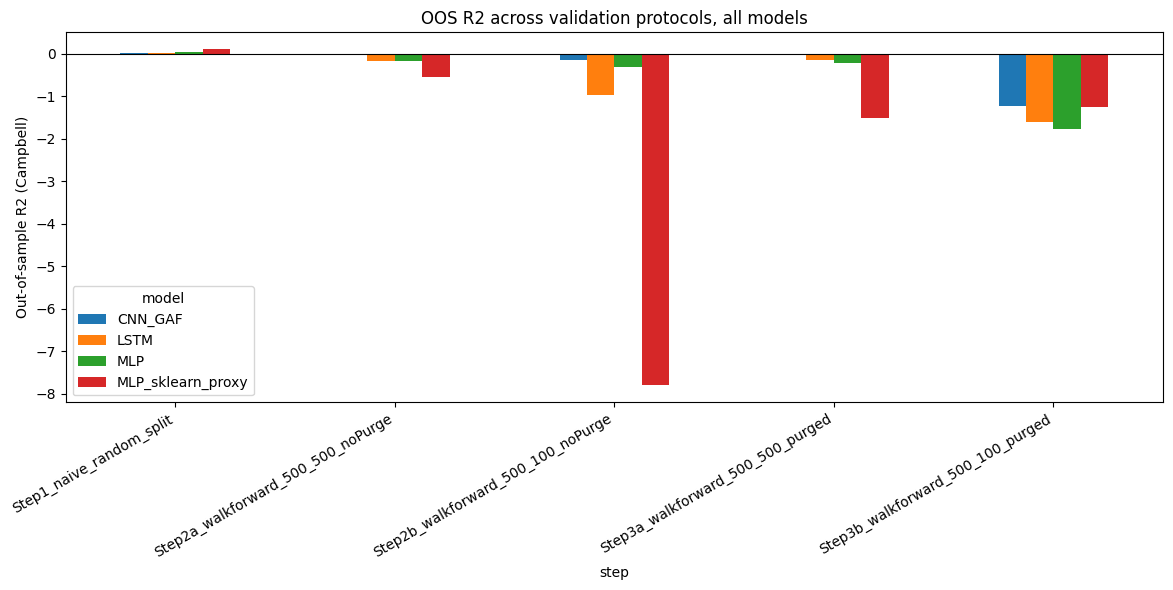

In [48]:
STEP_ORDER = [
    "Step1_naive_random_split",
    "Step2a_walkforward_500_500_noPurge",
    "Step2b_walkforward_500_100_noPurge",
    "Step3a_walkforward_500_500_purged",
    "Step3b_walkforward_500_100_purged",
]

pivot_r2 = all_results.pivot_table(index="step", columns="model", values="r2")
pivot_r2 = pivot_r2.reindex(STEP_ORDER)

ax = pivot_r2.plot(kind="bar", figsize=(12, 6))
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("Out-of-sample R2 (Campbell)")
ax.set_title("OOS R2 across validation protocols, all models")
plt.xticks(rotation=30, ha="right")
plt.legend(title="model")
plt.tight_layout()
plt.savefig(output_dir / "fig4_r2_all_models.png", dpi=120)
plt.show()